# Business Case 1: Segmenting Bank Clients

**Goal**: Segment bank customers using Unsupervised Machine Learning techniques.

We use:
- **Gower Distance** — designed for mixed categorical + numerical data
- **K-Medoids** — clustering algorithm robust to categorical data (unlike K-Means)
- **t-SNE** — dimensionality reduction for visualization
- **PCA** — additional dimensionality reduction and cluster profiling

In [1]:
# ── Install required libraries (run once in Colab) ──────────────────────────
!pip install gower kmedoids -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 476.3/476.3 kB 6.7 MB/s eta 0:00:00


In [2]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from kmedoids import KMedoids
from sklearn.metrics import silhouette_score

import gower

import warnings
warnings.filterwarnings('ignore')

print('✅ All libraries imported successfully')

✅ All libraries imported successfully


## 1. Load & Inspect the Data

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# ── Load data ─────────────────────────────────────────────────────────────────
# BUG FIX: use read_excel (not read_csv) and correct extension
df = pd.read_excel('/content/drive/MyDrive/Dataset1_BankClients[1].xlsx')

# Drop ID — not informative for clustering
df = df.drop(columns=['ID'])

print(f'Dataset shape: {df.shape}  ({df.shape[0]} clients, {df.shape[1]} features)')
print(f'\nMissing values:\n{df.isnull().sum()}')

Dataset shape: (5000, 17)  (5000 clients, 17 features)

Missing values:
Age            0
Gender         0
Job            0
Area           0
CitySize       0
FamilySize     0
Income         0
Wealth         0
Debt           0
FinEdu         0
ESG            0
Digital        0
BankFriend     0
LifeStyle      0
Luxury         0
Saving         0
Investments    0
dtype: int64


In [5]:
# ── First 5 rows ──────────────────────────────────────────────────────────────
print('--- Prime 5 righe del dataset ---')
display(df.head())

print('\n--- Statistiche Descrittive (Media, Min, Max) ---')
display(df.describe().round(2))

--- Prime 5 righe del dataset ---


,Age,Gender,Job,Area,CitySize,FamilySize,Income,Wealth,Debt,FinEdu,ESG,Digital,BankFriend,LifeStyle,Luxury,Saving,Investments
0,24,1,1,2,2,4,0.668046,0.702786,0.262070,0.741853,0.483684,0.698625,0.618259,0.607877,0.897369,0.283222,1
1,47,1,2,2,3,1,0.858453,0.915043,0.730430,0.859423,0.537167,0.959025,0.785936,0.862271,0.913729,0.821590,3
2,38,0,2,1,2,2,0.926818,0.898316,0.441272,0.485953,0.649434,0.750265,0.699725,0.755404,0.765199,0.503790,3
3,67,0,2,1,2,3,0.538797,0.423180,0.600401,0.493144,0.533829,0.590165,0.675353,0.334432,0.517209,0.691240,2
4,33,0,2,1,3,1,0.806659,0.731404,0.831449,0.856286,0.784940,0.710026,0.758793,0.908878,0.611610,0.615916,2



--- Statistiche Descrittive (Media, Min, Max) ---


,Age,Gender,Job,Area,CitySize,FamilySize,Income,Wealth,Debt,FinEdu,ESG,Digital,BankFriend,LifeStyle,Luxury,Saving,Investments
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,60.45,0.53,2.46,1.38,1.93,2.49,0.58,0.58,0.43,0.51,0.59,0.53,0.62,0.46,0.47,0.52,2.18
std,21.82,0.50,1.25,0.68,0.76,1.41,0.21,0.21,0.22,0.19,0.17,0.21,0.16,0.22,0.24,0.19,0.82
min,19.00,0.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.04,0.00,0.12,0.00,0.00,0.00,1.00
25%,42.00,0.00,2.00,1.00,1.00,1.00,0.41,0.42,0.26,0.37,0.47,0.37,0.51,0.28,0.27,0.40,1.00
50%,61.00,1.00,2.00,1.00,2.00,2.00,0.58,0.59,0.45,0.50,0.60,0.52,0.63,0.45,0.46,0.54,2.00
75%,80.00,1.00,2.00,2.00,3.00,3.00,0.75,0.75,0.60,0.65,0.71,0.70,0.75,0.64,0.66,0.66,3.00
max,95.00,1.00,5.00,3.00,3.00,6.00,0.98,1.00,0.98,0.96,0.99,0.97,0.97,0.99,1.00,0.97,3.00


## 2. Exploratory Data Analysis (EDA)

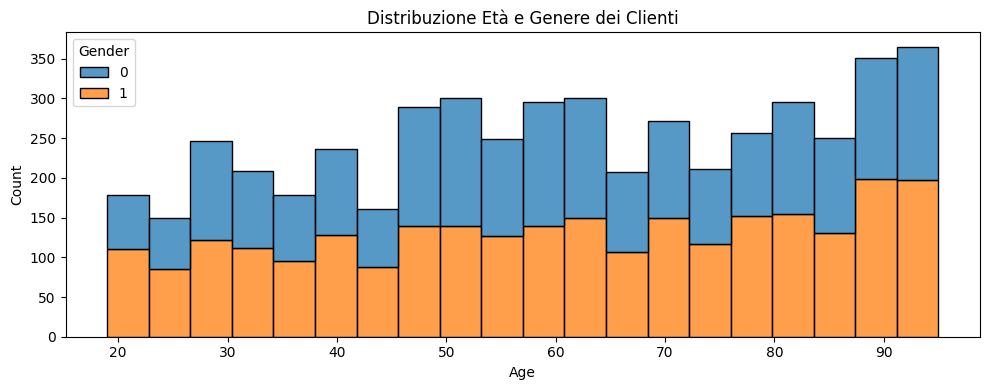

In [6]:
# ── Age & Gender distribution ─────────────────────────────────────────────────
plt.figure(figsize=(10, 4))
sns.histplot(data=df, x='Age', hue='Gender', multiple='stack', bins=20)
plt.title('Distribuzione Età e Genere dei Clienti')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

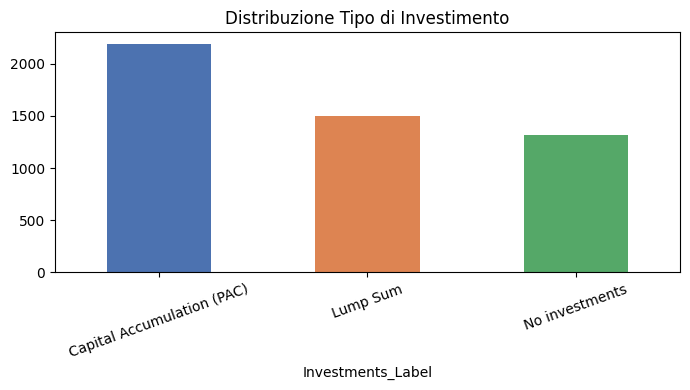

In [7]:
# ── Investment type distribution ──────────────────────────────────────────────
inv_labels = {1: 'No investments', 2: 'Lump Sum', 3: 'Capital Accumulation (PAC)'}
df['Investments_Label'] = df['Investments'].map(inv_labels)

plt.figure(figsize=(7, 4))
df['Investments_Label'].value_counts().plot(kind='bar', color=['#4C72B0','#DD8452','#55A868'])
plt.title('Distribuzione Tipo di Investimento')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Remove helper column
df = df.drop(columns=['Investments_Label'])

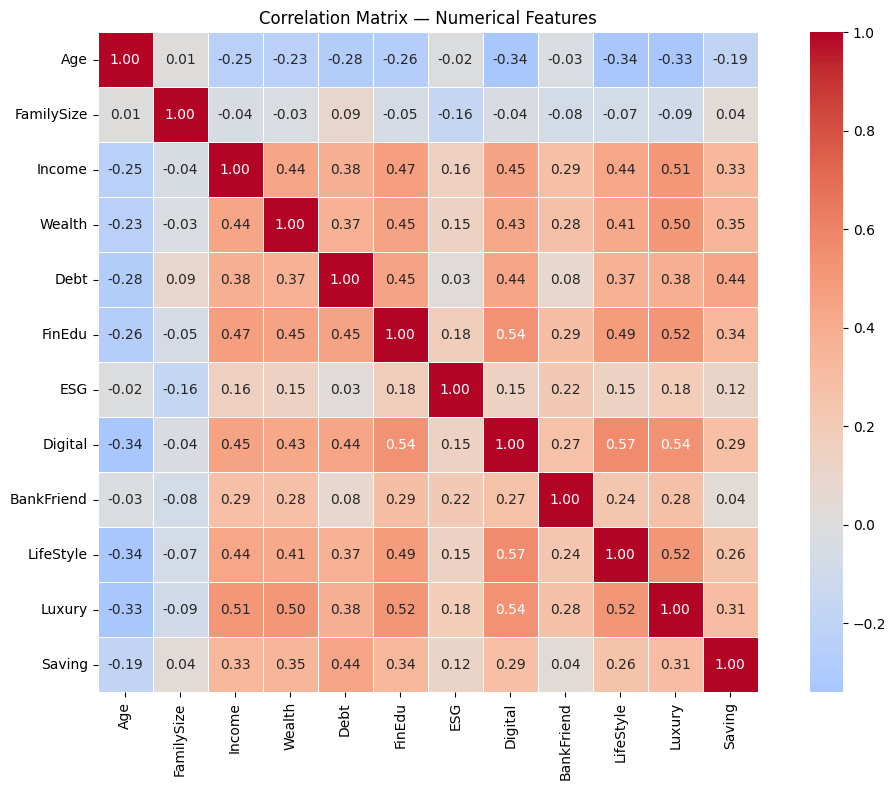

In [8]:
# ── Correlation heatmap (numerical features only) ─────────────────────────────
numerical_cols = ['Age', 'FamilySize', 'Income', 'Wealth', 'Debt',
                  'FinEdu', 'ESG', 'Digital', 'BankFriend', 'LifeStyle', 'Luxury', 'Saving']

plt.figure(figsize=(11, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix — Numerical Features')
plt.tight_layout()
plt.show()

## 3. Preprocessing

We split variables into:
- **Categorical**: `Gender`, `Job`, `Area`, `CitySize`, `Investments` → One-Hot Encoding
- **Numerical**: all others → MinMaxScaler (note: `Income`, `Wealth`, etc. are already normalized as percentiles, but `Age` and `FamilySize` are raw values and need scaling)

In [9]:
# ── Define categorical and numerical columns ───────────────────────────────────
categorical_columns = ['Gender', 'Job', 'Area', 'CitySize', 'Investments']

# BUG FIX: define categorical_features BEFORE using .astype()
categorical_features = df[categorical_columns].copy()
categorical_features = categorical_features.astype('category')

numerical_columns = [col for col in df.columns if col not in categorical_columns]
numerical_features = df[numerical_columns].copy()

print('Categorical columns:', categorical_columns)
print('Numerical columns:  ', numerical_columns)

Categorical columns: ['Gender', 'Job', 'Area', 'CitySize', 'Investments']
Numerical columns:   ['Age', 'FamilySize', 'Income', 'Wealth', 'Debt', 'FinEdu', 'ESG', 'Digital', 'BankFriend', 'LifeStyle', 'Luxury', 'Saving']


In [10]:
# ── Normalize numerical features ───────────────────────────────────────────────
# Age and FamilySize are raw (not in [0,1]) — scale everything consistently
scaler = MinMaxScaler()
X_num = scaler.fit_transform(numerical_features)

# ── One-Hot Encode categorical features ───────────────────────────────────────
# drop='first' applies dummy encoding (avoids multicollinearity)
encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
X_cat = encoder.fit_transform(categorical_features)

# ── Combine into final feature matrix ─────────────────────────────────────────
X = np.hstack((X_num, X_cat))

print(f'Numerical features shape : {X_num.shape}')
print(f'Categorical features shape: {X_cat.shape}')
print(f'Combined X shape          : {X.shape}')

Numerical features shape : (5000, 12)
Categorical features shape: (5000, 11)
Combined X shape          : (5000, 23)


## 4. Gower Distance

Standard distances (Euclidean, Manhattan) don't work well with mixed data.
**Gower Distance** handles both numerical (scaled absolute difference) and categorical (Jaccard) features, averaging them into a single distance in [0, 1].

This is the recommended approach from the course material.

In [11]:
# ── Compute Gower distance matrix ─────────────────────────────────────────────
# We pass the ORIGINAL dataframe (not one-hot encoded) so gower can detect
# which columns are categorical and apply the right sub-distance.

# Build a clean dataframe with correct dtypes for gower
df_gower = df.copy()
for col in categorical_columns:
    df_gower[col] = df_gower[col].astype('object')  # gower treats object as categorical

print('⏳ Computing Gower distance matrix (5000x5000) — this may take ~1-2 min...')
gower_distances = gower.gower_matrix(df_gower)
print(f'✅ Done. Distance matrix shape: {gower_distances.shape}')
print(f'   Min distance: {gower_distances[gower_distances > 0].min():.4f}')
print(f'   Max distance: {gower_distances.max():.4f}')
print(f'   Mean distance: {gower_distances.mean():.4f}')

⏳ Computing Gower distance matrix (5000x5000) — this may take ~1-2 min...
✅ Done. Distance matrix shape: (5000, 5000)
   Min distance: 0.0323
   Max distance: 0.7646
   Mean distance: 0.3415


## 5. Dimensionality Reduction: t-SNE with Gower Distance

We use t-SNE to visualize the high-dimensional data in 2D, using the precomputed Gower distance matrix.

⏳ Running t-SNE (2D) with Gower distance...
✅ t-SNE done.


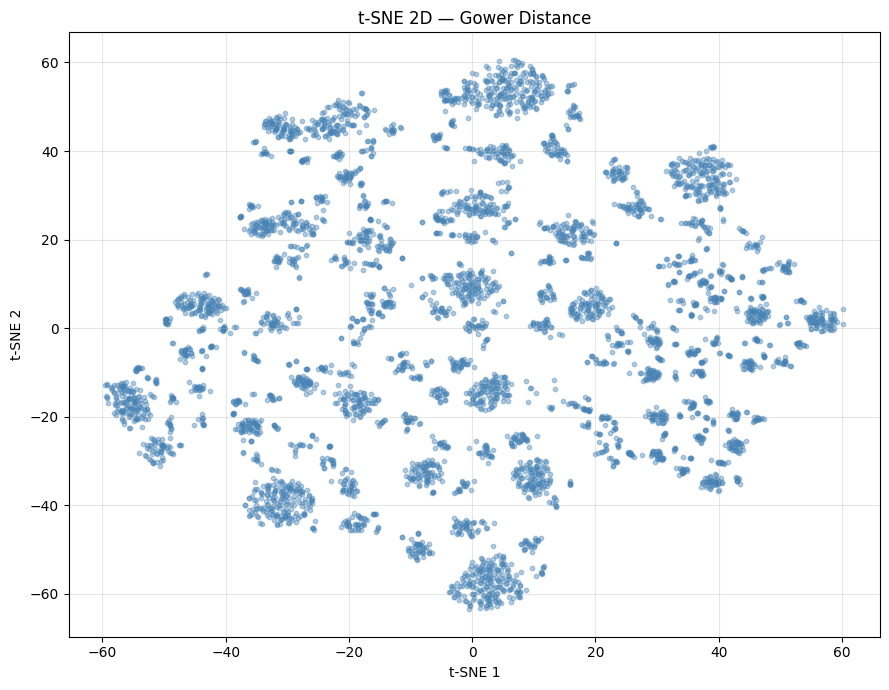

In [12]:
# ── t-SNE with Gower (2D) ─────────────────────────────────────────────────────
print('⏳ Running t-SNE (2D) with Gower distance...')
tsne_2d = TSNE(
    n_components=2,
    metric='precomputed',
    init='random',
    random_state=42,
    perplexity=40,        # tuned: good balance for 5000 points
    learning_rate='auto'
)
Y_2d = tsne_2d.fit_transform(gower_distances)
print('✅ t-SNE done.')

plt.figure(figsize=(9, 7))
plt.scatter(Y_2d[:, 0], Y_2d[:, 1], alpha=0.4, s=10, c='steelblue')
plt.title('t-SNE 2D — Gower Distance')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Choosing the Number of Clusters (Elbow + Silhouette)

We try K-Medoids with different values of k and evaluate:
- **Inertia** (Elbow method): lower = tighter clusters
- **Silhouette Score**: higher = better-separated clusters (range: -1 to 1)

In [13]:
# ── Elbow + Silhouette for K-Medoids ──────────────────────────────────────────
k_range = range(2, 9)
inertias = []
silhouettes = []

print('⏳ Testing k from 2 to 8...')
for k in k_range:
    kmed = KMedoids(
        n_clusters=k,
        metric='precomputed',
        method='pam',          # PAM = most robust k-medoids variant
        init='build',   # smart initialization (like k-means++)
        random_state=42
    )
    labels = kmed.fit_predict(gower_distances)
    inertias.append(kmed.inertia_)
    sil = silhouette_score(gower_distances, labels, metric='precomputed')
    silhouettes.append(sil)
    print(f'  k={k} | Inertia: {kmed.inertia_:.2f} | Silhouette: {sil:.4f}')

print('✅ Done.')

⏳ Testing k from 2 to 8...
  k=2 | Inertia: 1197.83 | Silhouette: 0.1356
  k=3 | Inertia: 1090.27 | Silhouette: 0.1340
  k=4 | Inertia: 1018.65 | Silhouette: 0.1463
  k=5 | Inertia: 980.60 | Silhouette: 0.1278
  k=6 | Inertia: 944.00 | Silhouette: 0.1157
  k=7 | Inertia: 917.56 | Silhouette: 0.1236
  k=8 | Inertia: 893.13 | Silhouette: 0.1155
✅ Done.


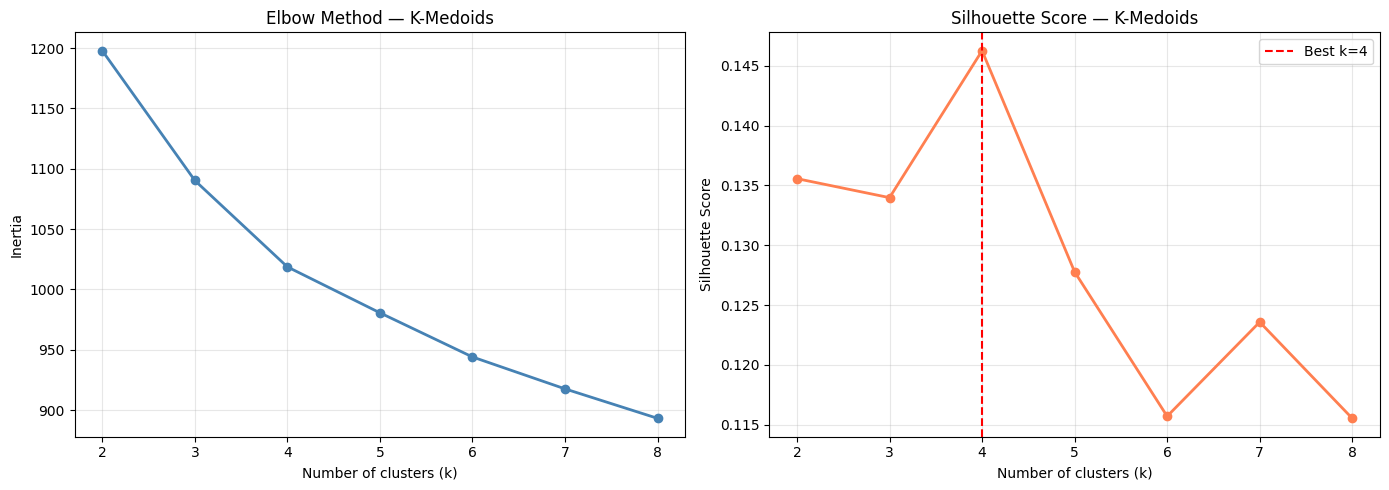

→ Best k by Silhouette: k=4


In [14]:
# ── Plot Elbow and Silhouette ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(list(k_range), inertias, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Elbow Method — K-Medoids')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, alpha=0.3)

# Silhouette
axes[1].plot(list(k_range), silhouettes, marker='o', color='coral', linewidth=2)
axes[1].set_title('Silhouette Score — K-Medoids')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)

# Mark best silhouette
best_k = list(k_range)[np.argmax(silhouettes)]
axes[1].axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f'→ Best k by Silhouette: k={best_k}')

## 7. K-Medoids Clustering (Final Model)

We fit K-Medoids with the best k found above, using the Gower precomputed distance matrix.

In [15]:
# ── Final K-Medoids model ──────────────────────────────────────────────────────
# You can override best_k here if domain knowledge suggests a different value
N_CLUSTERS = best_k  # or set manually e.g. N_CLUSTERS = 4

kmed_final = KMedoids(
    n_clusters=N_CLUSTERS,
    metric='precomputed',
    method='pam',
    init='build',
    random_state=42
)

print(f'⏳ Fitting K-Medoids with k={N_CLUSTERS}...')
cluster_labels = kmed_final.fit_predict(gower_distances)
print('✅ Clustering done.')

# Add cluster labels to original dataframe
df['Cluster'] = cluster_labels

# Cluster sizes
print('\nCluster sizes:')
print(df['Cluster'].value_counts().sort_index())

⏳ Fitting K-Medoids with k=4...
✅ Clustering done.

Cluster sizes:
Cluster
0    1681
1    1257
2     865
3    1197
Name: count, dtype: int64


## 8. Visualize Clusters with t-SNE

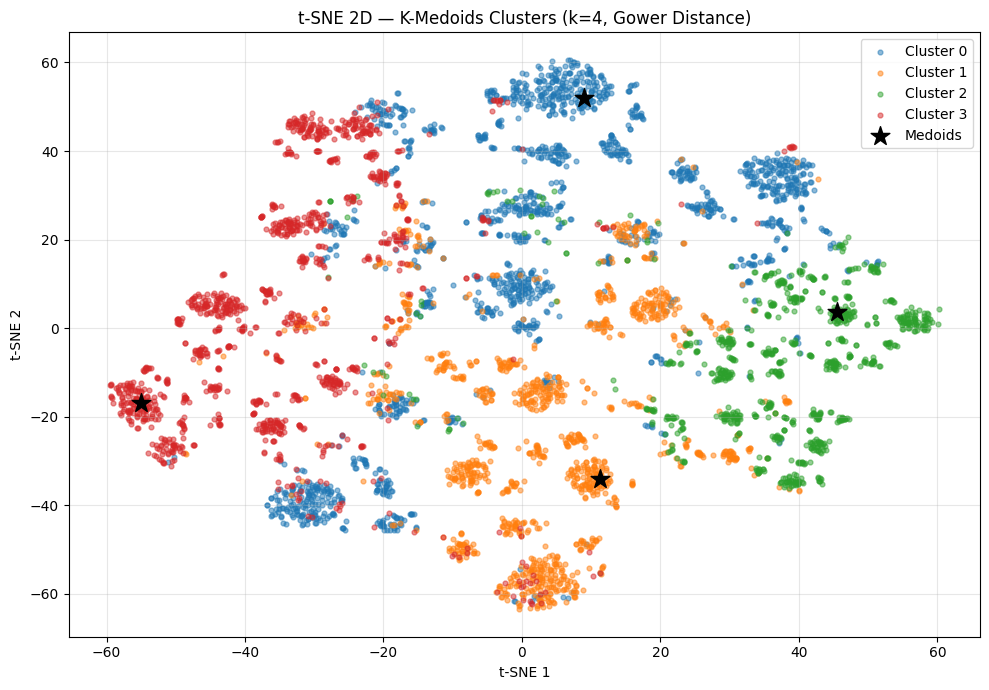

In [16]:
# ── t-SNE coloured by cluster ──────────────────────────────────────────────────
palette = sns.color_palette('tab10', N_CLUSTERS)

plt.figure(figsize=(10, 7))
for c in range(N_CLUSTERS):
    mask = cluster_labels == c
    plt.scatter(Y_2d[mask, 0], Y_2d[mask, 1],
                label=f'Cluster {c}', alpha=0.5, s=12,
                color=palette[c])

# Mark medoids
medoid_indices = kmed_final.medoid_indices_
plt.scatter(Y_2d[medoid_indices, 0], Y_2d[medoid_indices, 1],
            s=200, marker='*', c='black', zorder=5, label='Medoids')

plt.title(f't-SNE 2D — K-Medoids Clusters (k={N_CLUSTERS}, Gower Distance)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. PCA — Dimensionality Reduction & Cluster Visualization

PCA is applied on the encoded feature matrix X (numerical + one-hot categorical) for visualization. Unlike t-SNE, PCA is linear and lets us inspect which variables drive variance.

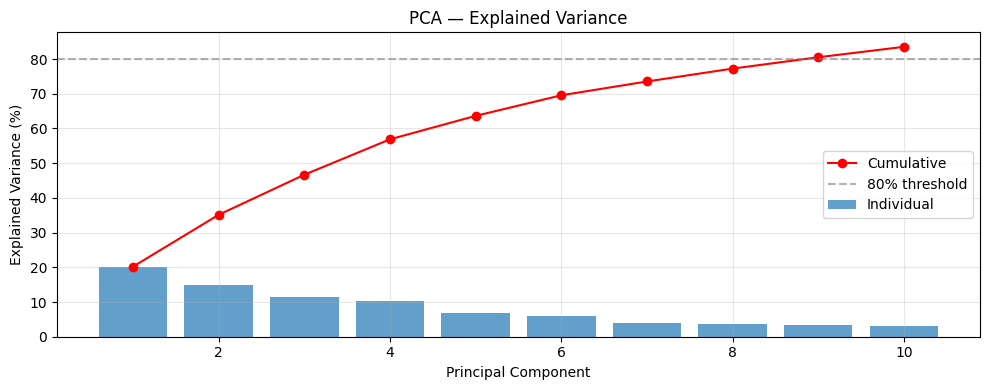

Cumulative explained variance:
  PC1–PC1: 20.2%
  PC1–PC2: 35.1%
  PC1–PC3: 46.7%
  PC1–PC4: 56.9%
  PC1–PC5: 63.6%
  PC1–PC6: 69.5%
  PC1–PC7: 73.5%
  PC1–PC8: 77.2%
  PC1–PC9: 80.5%
  PC1–PC10: 83.5%


In [17]:
# ── PCA ────────────────────────────────────────────────────────────────────────
pca = PCA(n_components=10, random_state=42)
X_pca_full = pca.fit_transform(X)

# Explained variance
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

plt.figure(figsize=(10, 4))
plt.bar(range(1, 11), explained * 100, alpha=0.7, label='Individual')
plt.plot(range(1, 11), cumulative * 100, marker='o', color='red', label='Cumulative')
plt.axhline(80, linestyle='--', color='gray', alpha=0.6, label='80% threshold')
plt.title('PCA — Explained Variance')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Cumulative explained variance:')
for i, c in enumerate(cumulative):
    print(f'  PC1–PC{i+1}: {c*100:.1f}%')

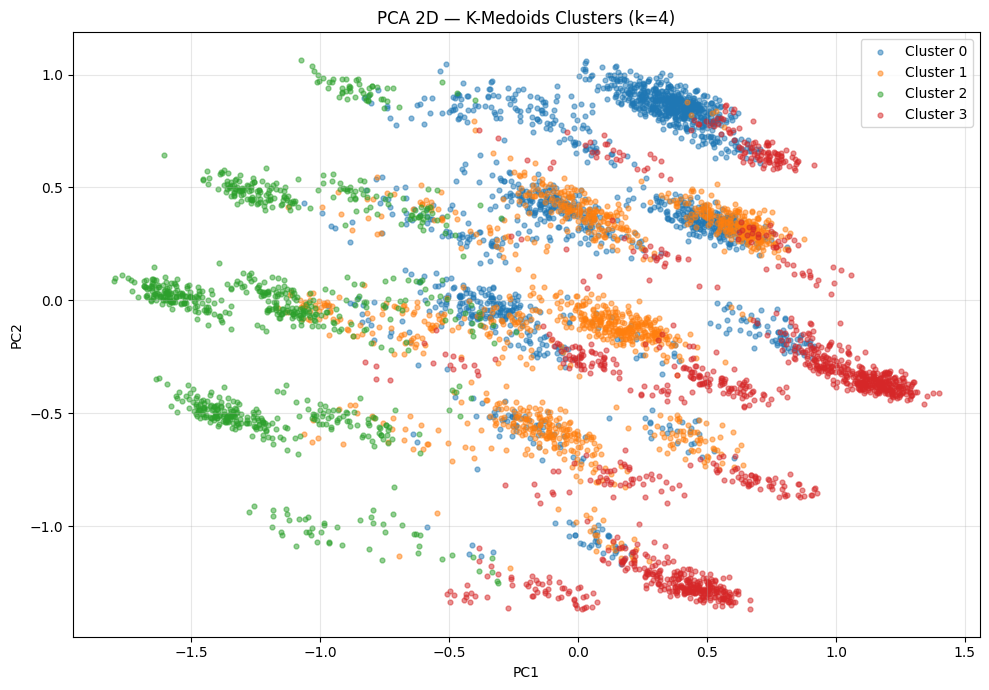

In [18]:
# ── PCA 2D scatter coloured by cluster ────────────────────────────────────────
X_pca_2d = X_pca_full[:, :2]

plt.figure(figsize=(10, 7))
for c in range(N_CLUSTERS):
    mask = cluster_labels == c
    plt.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                label=f'Cluster {c}', alpha=0.5, s=12,
                color=palette[c])

plt.title(f'PCA 2D — K-Medoids Clusters (k={N_CLUSTERS})')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

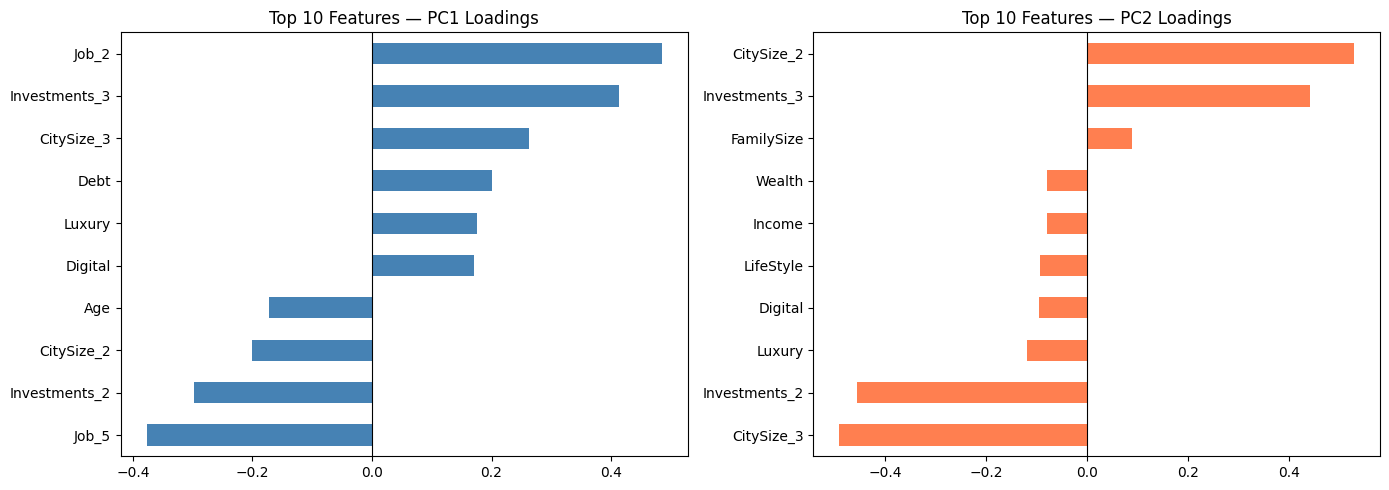

In [19]:
# ── PCA Loadings — which variables drive PC1 and PC2? ─────────────────────────
feature_names_num = numerical_columns
feature_names_cat = encoder.get_feature_names_out(categorical_columns).tolist()
all_feature_names = feature_names_num + feature_names_cat

loadings = pd.DataFrame(
    pca.components_[:2].T,
    index=all_feature_names,
    columns=['PC1', 'PC2']
)

# Top 10 features by absolute loading on PC1
top_pc1 = loadings['PC1'].abs().nlargest(10).index

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
loadings.loc[top_pc1, 'PC1'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 Features — PC1 Loadings')
axes[0].axvline(0, color='black', linewidth=0.8)

top_pc2 = loadings['PC2'].abs().nlargest(10).index
loadings.loc[top_pc2, 'PC2'].sort_values().plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Top 10 Features — PC2 Loadings')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

## 10. Cluster Profiling & Interpretation

We analyse the mean/mode of each variable per cluster to understand what characterises each segment.

In [20]:
# ── Cluster profiles — numerical means ────────────────────────────────────────
profile_num = df.groupby('Cluster')[numerical_columns].mean().round(3)
print('--- Cluster Profiles (Numerical — Normalized Means) ---')
display(profile_num.T)

--- Cluster Profiles (Numerical — Normalized Means) ---


Cluster,0,1,2,3
Age,60.111,58.056,78.754,50.215
FamilySize,2.924,2.628,2.037,2.057
Income,0.560,0.548,0.392,0.760
Wealth,0.579,0.533,0.395,0.762
Debt,0.465,0.456,0.144,0.557
FinEdu,0.495,0.479,0.341,0.689
ESG,0.550,0.527,0.620,0.679
Digital,0.502,0.499,0.319,0.744
BankFriend,0.583,0.558,0.636,0.721
LifeStyle,0.430,0.446,0.265,0.667


In [21]:
# ── Cluster profiles — categorical modes ──────────────────────────────────────
job_map  = {1:'Unemployed', 2:'Employee', 3:'Manager', 4:'Entrepreneur', 5:'Retired'}
area_map = {1:'Nord', 2:'Centro', 3:'Sud/Isole'}
city_map = {1:'Small', 2:'Medium', 3:'Large'}
inv_map  = {1:'No invest.', 2:'Lump Sum', 3:'Capital Acc.'}
gen_map  = {0:'Male', 1:'Female'}

df['Job_L']  = df['Job'].map(job_map)
df['Area_L'] = df['Area'].map(area_map)
df['City_L'] = df['CitySize'].map(city_map)
df['Inv_L']  = df['Investments'].map(inv_map)
df['Gen_L']  = df['Gender'].map(gen_map)

profile_cat = df.groupby('Cluster')[['Gen_L','Job_L','Area_L','City_L','Inv_L']].agg(lambda x: x.mode()[0])
print('--- Cluster Profiles (Categorical — Mode) ---')
display(profile_cat)

--- Cluster Profiles (Categorical — Mode) ---


,Gen_L,Job_L,Area_L,City_L,Inv_L
Cluster,,,,,
0,Female,Employee,Nord,Medium,Capital Acc.
1,Male,Employee,Nord,Small,No invest.
2,Female,Retired,Nord,Medium,Lump Sum
3,Male,Employee,Nord,Large,Capital Acc.


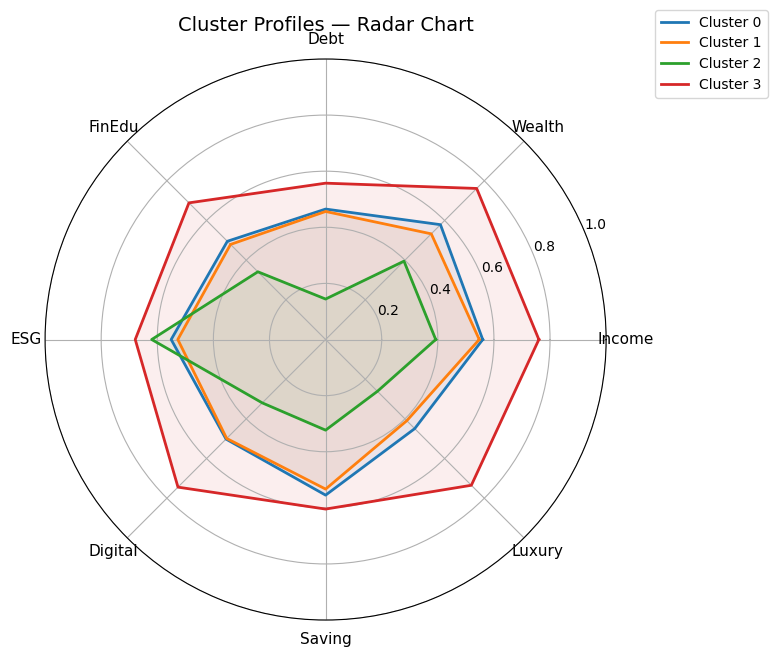

In [22]:
# ── Radar chart: cluster profiles on key numerical variables ──────────────────
key_vars = ['Income', 'Wealth', 'Debt', 'FinEdu', 'ESG', 'Digital', 'Saving', 'Luxury']
cluster_means = df.groupby('Cluster')[key_vars].mean()

angles = np.linspace(0, 2 * np.pi, len(key_vars), endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for c in range(N_CLUSTERS):
    values = cluster_means.loc[c].tolist()
    values += values[:1]
    ax.plot(angles, values, label=f'Cluster {c}', linewidth=2, color=palette[c])
    ax.fill(angles, values, alpha=0.08, color=palette[c])

ax.set_thetagrids(np.degrees(angles[:-1]), key_vars, size=11)
ax.set_ylim(0, 1)
ax.set_title('Cluster Profiles — Radar Chart', size=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

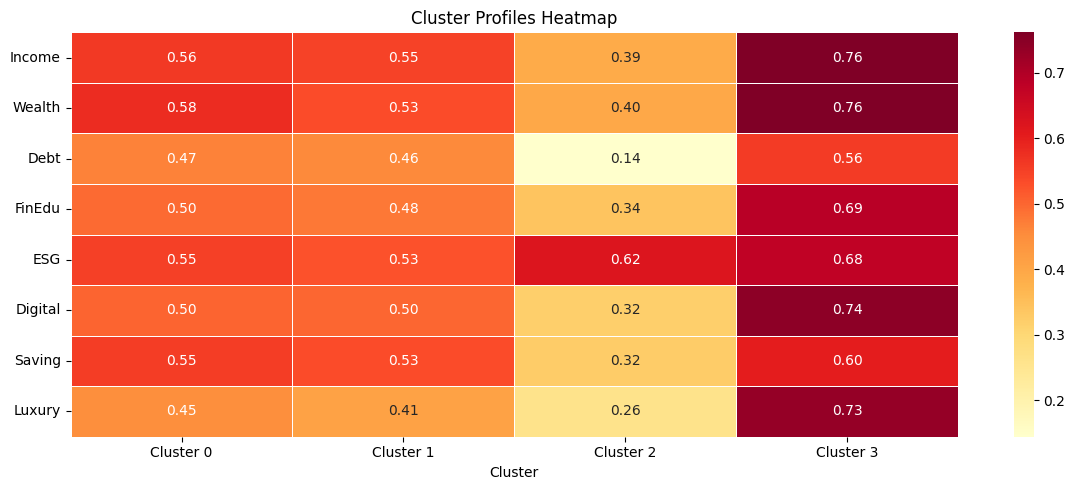

In [23]:
# ── Heatmap of cluster profiles ────────────────────────────────────────────────
plt.figure(figsize=(12, 5))
sns.heatmap(cluster_means[key_vars].T,
            annot=True, fmt='.2f',
            cmap='YlOrRd',
            xticklabels=[f'Cluster {c}' for c in range(N_CLUSTERS)],
            linewidths=0.5)
plt.title('Cluster Profiles Heatmap')
plt.tight_layout()
plt.show()

In [24]:
# ── Medoid profiles — the representative client of each cluster ───────────────
medoid_profiles = df.iloc[kmed_final.medoid_indices_].copy().reset_index(drop=True)
medoid_profiles.index.name = 'Cluster'
print('--- Medoid Profiles (Representative Client per Cluster) ---')
display(medoid_profiles[numerical_columns + ['Gen_L','Job_L','Area_L','City_L','Inv_L']])

--- Medoid Profiles (Representative Client per Cluster) ---


,Age,FamilySize,Income,Wealth,Debt,FinEdu,ESG,Digital,BankFriend,LifeStyle,Luxury,Saving,Gen_L,Job_L,Area_L,City_L,Inv_L
Cluster,,,,,,,,,,,,,,,,,
0,70,3,0.442296,0.667260,0.373311,0.529557,0.622244,0.379909,0.701953,0.312721,0.439937,0.532308,Female,Employee,Nord,Medium,Capital Acc.
1,53,1,0.606499,0.418081,0.443457,0.556508,0.544906,0.487718,0.569354,0.599387,0.314667,0.519828,Male,Employee,Nord,Small,No invest.
2,73,1,0.407312,0.228185,0.194438,0.381688,0.731963,0.335502,0.720185,0.219611,0.204991,0.253147,Female,Retired,Nord,Medium,Lump Sum
3,51,2,0.817226,0.812271,0.540330,0.660666,0.740343,0.712418,0.711609,0.742132,0.869339,0.711956,Male,Employee,Nord,Large,Capital Acc.


## 11. Summary & Business Interpretation

Use the profiles above to assign a **meaningful business label** to each cluster, for example:

| Cluster | Possible Label | Key Signals |
|---------|---------------|-------------|
| 0 | Young Mass | Low income, low wealth, no investments |
| 1 | Mass Affluent | Medium income, capital accumulation |
| 2 | Affluent / Investor | High wealth, high FinEdu, lump sum |
| 3 | Retired Saver | Older, high saving, low debt |

> Adapt labels to what you observe in the actual cluster means and modes above.

In [25]:
# ── Final model quality summary ────────────────────────────────────────────────
final_sil = silhouette_score(gower_distances, cluster_labels, metric='precomputed')

print('=' * 50)
print(f'  K-Medoids  |  k = {N_CLUSTERS}')
print(f'  Distance   |  Gower')
print(f'  Inertia    |  {kmed_final.inertia_:.4f}')
print(f'  Silhouette |  {final_sil:.4f}')
print('=' * 50)
print('\nCluster sizes:')
print(df['Cluster'].value_counts().sort_index().to_string())

  K-Medoids  |  k = 4
  Distance   |  Gower
  Inertia    |  1018.6542
  Silhouette |  0.1463

Cluster sizes:
Cluster
0    1681
1    1257
2     865
3    1197
